# Pothole Detection using YOLOv8

This notebook implements an end-to-end computer vision workflow for detecting **potholes in road images** using YOLOv8.

The workflow includes:
- dataset upload and extraction,
- Pascal VOC XML to YOLO label conversion,
- reproducible train/validation splitting,
- annotation sanity checking,
- YOLOv8n training,
- validation/inference,
- visualization of detected potholes,
- and exploratory post-detection texture/severity analysis.

> **Academic project:** This notebook is intended for learning, experimentation, and portfolio demonstration.


## 1. Environment setup


In [ ]:
# Install required libraries (run once per Colab session)
!pip -q install -U ultralytics opencv-python lxml scikit-image matplotlib


## 2. Upload and extract the dataset


In [ ]:
from google.colab import files

# Upload the Kaggle-downloaded ZIP file (e.g., pothole-detection.zip)
uploaded = files.upload()

# Get the uploaded ZIP filename automatically
ZIP_NAME = next(iter(uploaded.keys()))
print("Uploaded ZIP:", ZIP_NAME)


In [ ]:
!mkdir -p /content/data


In [ ]:
# Extract the uploaded ZIP file into /content/data
!unzip -o "$ZIP_NAME" -d /content/data


## 3. Inspect the extracted data


In [ ]:
# Confirm extracted folders
!ls -la /content/data


total 64
drwxr-xr-x 4 root root  4096 Jan 11 14:21 .
drwxr-xr-x 1 root root  4096 Jan 11 14:21 ..
drwxr-xr-x 2 root root 28672 Jan 11 14:32 annotations
drwxr-xr-x 2 root root 24576 Jan 11 14:32 images


In [ ]:
import glob, os

imgs = glob.glob("/content/data/**/images/*.jpg", recursive=True) + glob.glob("/content/data/**/images/*.png", recursive=True)      + glob.glob("/content/data/images/*.jpg") + glob.glob("/content/data/images/*.png")

xmls = glob.glob("/content/data/**/annotations/*.xml", recursive=True) + glob.glob("/content/data/annotations/*.xml")

print("Images:", len(imgs))
print("XML annotations:", len(xmls))
print("Sample image:", imgs[0] if imgs else None)
print("Sample XML:", xmls[0] if xmls else None)


Images: 1330
XML annotations: 1330
Sample image: /content/data/images/potholes201.png
Sample XML: /content/data/annotations/potholes200.xml


## 4. Convert Pascal VOC annotations to YOLO format


In [ ]:
import xml.etree.ElementTree as ET
from pathlib import Path
import shutil, random

# Locate images and annotations folders (supports common extracted structures)
possible_img_dirs = [
    Path("/content/data/images"),
    Path("/content/data/pothole-detection/images"),
]
possible_ann_dirs = [
    Path("/content/data/annotations"),
    Path("/content/data/pothole-detection/annotations"),
]

IMG_DIR = next((p for p in possible_img_dirs if p.exists()), None)
ANN_DIR = next((p for p in possible_ann_dirs if p.exists()), None)

if IMG_DIR is None or ANN_DIR is None:
    raise FileNotFoundError("Could not find 'images' and 'annotations' folders inside /content/data. Check the unzip output.")

print("IMG_DIR:", IMG_DIR)
print("ANN_DIR:", ANN_DIR)

# Output YOLO structure
YOLO_ROOT = Path("/content/pothole_yolo")
for p in [YOLO_ROOT/"images/train", YOLO_ROOT/"images/val",
          YOLO_ROOT/"labels/train", YOLO_ROOT/"labels/val"]:
    p.mkdir(parents=True, exist_ok=True)

# One class only
CLASS_MAP = {"pothole": 0, "Potholes": 0, "Pothole": 0}

def voc_to_yolo(w, h, xmin, ymin, xmax, ymax):
    bw = xmax - xmin
    bh = ymax - ymin
    xc = xmin + bw/2
    yc = ymin + bh/2
    return xc/w, yc/h, bw/w, bh/h

# Create pairs (image, xml)
img_files = sorted(list(IMG_DIR.glob("*.jpg")) + list(IMG_DIR.glob("*.png")))
xml_by_stem = {x.stem: x for x in ANN_DIR.glob("*.xml")}

pairs = [(img, xml_by_stem[img.stem]) for img in img_files if img.stem in xml_by_stem]
print("Matched pairs:", len(pairs))

# Train/val split (80/20)
random.seed(42)
random.shuffle(pairs)
split = int(0.8 * len(pairs))
train_pairs = pairs[:split]
val_pairs = pairs[split:]

def process(pairs, split_name):
    for img_path, xml_path in pairs:
        # copy image
        shutil.copy(img_path, YOLO_ROOT / f"images/{split_name}" / img_path.name)

        # parse xml -> yolo txt
        root = ET.parse(xml_path).getroot()
        size = root.find("size")
        w = int(size.find("width").text)
        h = int(size.find("height").text)

        lines = []
        for obj in root.findall("object"):
            name = obj.find("name").text
            if name not in CLASS_MAP:
                continue
            cls = CLASS_MAP[name]

            bnd = obj.find("bndbox")
            xmin = float(bnd.find("xmin").text)
            ymin = float(bnd.find("ymin").text)
            xmax = float(bnd.find("xmax").text)
            ymax = float(bnd.find("ymax").text)

            xc, yc, bw, bh = voc_to_yolo(w, h, xmin, ymin, xmax, ymax)
            lines.append(f"{cls} {xc:.6f} {yc:.6f} {bw:.6f} {bh:.6f}")

        (YOLO_ROOT / f"labels/{split_name}" / f"{img_path.stem}.txt").write_text("\n".join(lines))

process(train_pairs, "train")
process(val_pairs, "val")

print("Train images:", len(list((YOLO_ROOT/'images/train').glob('*'))))
print("Val images:", len(list((YOLO_ROOT/'images/val').glob('*'))))
print("Train labels:", len(list((YOLO_ROOT/'labels/train').glob('*'))))
print("Val labels:", len(list((YOLO_ROOT/'labels/val').glob('*'))))


IMG_DIR: /content/data/images
ANN_DIR: /content/data/annotations
Matched pairs: 665
Train images: 532
Val images: 133
Train labels: 532
Val labels: 133


In [ ]:
from pathlib import Path

yaml_text = """path: /content/pothole_yolo
train: images/train
val: images/val

names:
  0: pothole
"""

Path("/content/pothole_yolo/data.yaml").write_text(yaml_text)
print(yaml_text)


path: /content/pothole_yolo
train: images/train
val: images/val

names:
  0: pothole



## 5. Sanity-check the converted bounding boxes


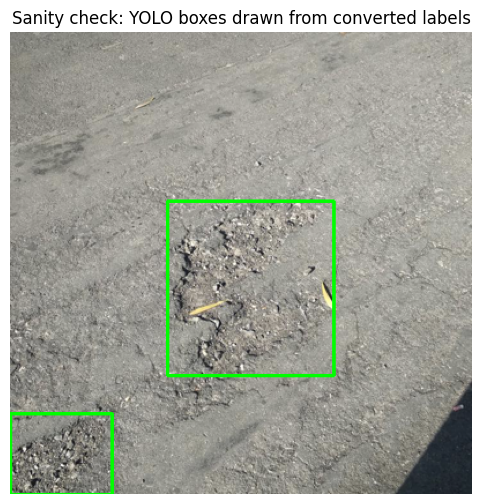

In [ ]:
import cv2, random
import matplotlib.pyplot as plt
from pathlib import Path

img_paths = list(Path("/content/pothole_yolo/images/train").glob("*"))

for attempt in range(5):
    img_path = random.choice(img_paths)
    label_path = Path("/content/pothole_yolo/labels/train") / (img_path.stem + ".txt")

    img = cv2.imread(str(img_path))
    h, w = img.shape[:2]

    if label_path.exists() and label_path.read_text().strip() != "":
        for line in label_path.read_text().strip().splitlines():
            cls, xc, yc, bw, bh = map(float, line.split())
            x1 = int((xc - bw/2) * w)
            y1 = int((yc - bh/2) * h)
            x2 = int((xc + bw/2) * w)
            y2 = int((yc + bh/2) * h)
            cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)

        plt.figure(figsize=(10,6))
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        plt.title("Sanity check: YOLO boxes drawn from converted labels")
        plt.axis("off")
        plt.show()
        break
else:
    print("Could not find a labeled image in 5 tries (rare). Try running this cell again.")


## 6. Train YOLOv8n


In [ ]:
from ultralytics import YOLO
import ultralytics
print("Ultralytics version:", ultralytics.__version__)
print("YOLO imported successfully!")


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics version: 8.3.252
YOLO imported successfully!


In [ ]:
from ultralytics import YOLO
from pathlib import Path

model = YOLO("yolov8n.pt")

results = model.train(
    data="/content/pothole_yolo/data.yaml",
    epochs=30,
    imgsz=640,
    batch=16,
    project="/content/pothole_runs",
    name="train",
    exist_ok=True
)

BEST_WEIGHTS = Path("/content/pothole_runs/train/weights/best.pt")
print("Best weights:", BEST_WEIGHTS)


In [ ]:
# Evaluate the best checkpoint on the validation set
best_model = YOLO(str(BEST_WEIGHTS))
metrics = best_model.val(data="/content/pothole_yolo/data.yaml")

print("mAP@50:", float(metrics.box.map50))
print("mAP@50-95:", float(metrics.box.map))


## 7. Run inference on validation images


In [ ]:
from ultralytics import YOLO
from pathlib import Path

BEST_WEIGHTS = Path("/content/pothole_runs/train/weights/best.pt")
model = YOLO(str(BEST_WEIGHTS))

pred_results = model.predict(
    source="/content/pothole_yolo/images/val",
    conf=0.25,
    save=True,
    project="/content/pothole_runs",
    name="predict",
    exist_ok=True
)

print("Predictions saved to:", Path("/content/pothole_runs/predict"))


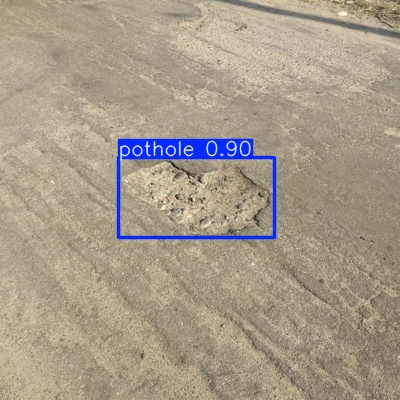

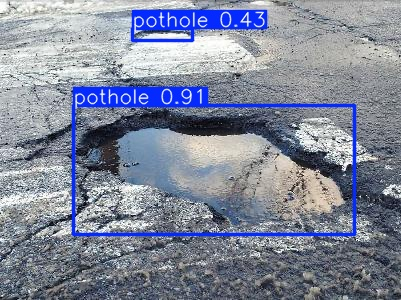

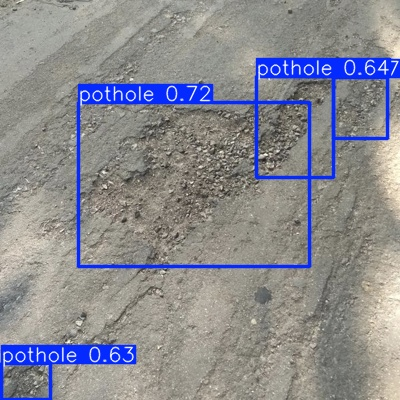

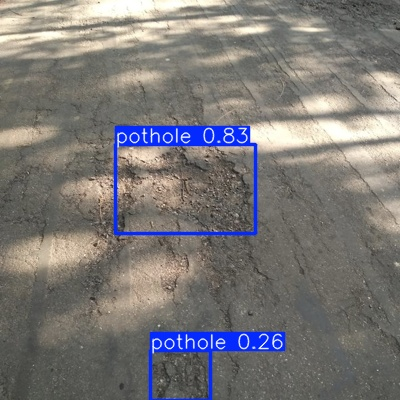

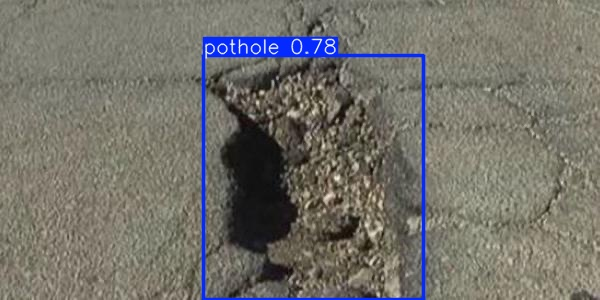

In [ ]:
import glob
from IPython.display import Image, display

preds = glob.glob("/content/pothole_runs/predict/*.jpg") + glob.glob("/content/pothole_runs/predict/*.png")
print("Num prediction images:", len(preds))

for p in preds[:5]:
    display(Image(filename=p, width=900))


## 8. Inspect a high-confidence detected pothole



image 1/1 /content/pothole_yolo/images/val/potholes33.png: 640x640 3 potholes, 7.2ms
Speed: 2.2ms preprocess, 7.2ms inference, 1.2ms postprocess per image at shape (1, 3, 640, 640)


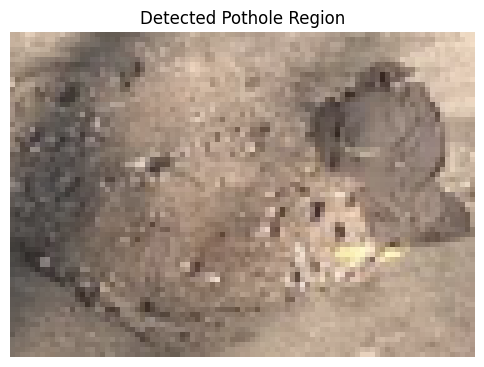

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import random, glob
from pathlib import Path
from ultralytics import YOLO

BEST_WEIGHTS = Path("/content/pothole_runs/train/weights/best.pt")
model = YOLO(str(BEST_WEIGHTS))

# Randomly pick a validation image (png or jpg)
val_images = glob.glob("/content/pothole_yolo/images/val/*.png") + glob.glob("/content/pothole_yolo/images/val/*.jpg")
if not val_images:
    raise FileNotFoundError("No validation images found in /content/pothole_yolo/images/val")

# Try a few random images until we get at least one detection
img_path = None
res = None
for _ in range(10):
    candidate = random.choice(val_images)
    r = model(candidate)[0]
    if r.boxes is not None and len(r.boxes) > 0:
        img_path = candidate
        res = r
        break

if img_path is None:
    raise RuntimeError("No pothole detections found in 10 random validation images. Try lowering conf threshold or training longer.")

print("Analyzing:", img_path)

img = cv2.imread(img_path)

# Choose the highest-confidence detection
boxes = res.boxes.xyxy.cpu().numpy()
confs = res.boxes.conf.cpu().numpy()
best_i = int(np.argmax(confs))
x1, y1, x2, y2 = map(int, boxes[best_i])

crop = img[y1:y2, x1:x2]

plt.figure(figsize=(6,6))
plt.imshow(cv2.cvtColor(crop, cv2.COLOR_BGR2RGB))
plt.title(f"Detected Pothole Region (conf={confs[best_i]:.2f})")
plt.axis("off")
plt.show()


## 9. Exploratory post-detection image analysis


The following cells explore the detected pothole region using classical image-processing techniques.  
These steps are supplementary to the YOLO detector and are not part of the detector's training pipeline.


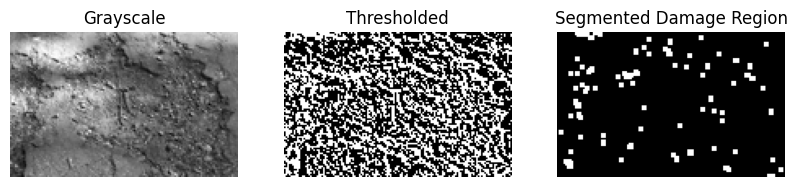

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

gray = cv2.cvtColor(crop, cv2.COLOR_BGR2GRAY)

# Reduce noise (helps segmentation)
blur = cv2.GaussianBlur(gray, (5,5), 0)

# Adaptive threshold (handles uneven lighting)
th = cv2.adaptiveThreshold(
    blur, 255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY_INV,
    11, 2
)

kernel = np.ones((3,3), np.uint8)
open_ = cv2.morphologyEx(th, cv2.MORPH_OPEN, kernel, iterations=1)
clean = cv2.morphologyEx(open_, cv2.MORPH_CLOSE, kernel, iterations=2)

plt.figure(figsize=(12,4))
plt.subplot(1,3,1); plt.imshow(gray, cmap="gray"); plt.title("Grayscale"); plt.axis("off")
plt.subplot(1,3,2); plt.imshow(th, cmap="gray"); plt.title("Thresholded"); plt.axis("off")
plt.subplot(1,3,3); plt.imshow(clean, cmap="gray"); plt.title("Segmented Damage Region"); plt.axis("off")
plt.show()


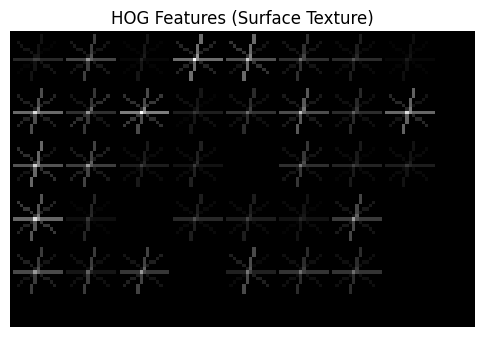

HOG feature vector length: 1008


In [ ]:
from skimage.feature import hog
import matplotlib.pyplot as plt

hog_features, hog_image = hog(
    clean,
    orientations=9,
    pixels_per_cell=(16,16),
    cells_per_block=(2,2),
    visualize=True
)

plt.figure(figsize=(6,6))
plt.imshow(hog_image, cmap="gray")
plt.title("HOG Features (Surface Texture)")
plt.axis("off")
plt.show()

print("HOG feature vector length:", len(hog_features))


In [ ]:
import cv2
import numpy as np

contours, _ = cv2.findContours(clean, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

if not contours:
    print("No contours found in the segmented mask (try a different image or adjust thresholding).")
else:
    cnt = max(contours, key=cv2.contourArea)
    area = cv2.contourArea(cnt)
    perimeter = cv2.arcLength(cnt, True)

    severity_score = area / (crop.shape[0] * crop.shape[1] + 1e-9)

    print("Pothole Area:", int(area))
    print("Perimeter:", int(perimeter))
    print("Severity Score (area / ROI area):", round(severity_score, 3))


Pothole Area: 31
Perimeter: 42
Severity Score: 0.002
